# 单车骑行活动的空间密度分布

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
df2=pd.read_csv('北京边界数据.csv')   #北京边界
bj_x=df2["x"].tolist()
bj_y=df2["y"].tolist()

In [3]:
cy=39.91667   #北京市中心坐标
cx=116.41667

In [2]:
df=pd.read_csv('df.csv')   #筛选数据后的单车数据
df

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,Travel_time(s),speed
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,2.727397
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,3.013957
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,1.792963
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,2.972972
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,3.661382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094262,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,3.176235
3094263,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,0.844479
3094264,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,2.999509
3094265,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,3.842861


In [5]:
sx=df["start_x"].tolist()   #起始坐标
sy=df["start_y"].tolist()   
ex=df["end_x"].tolist()    #终点坐标
ey=df["end_y"].tolist()

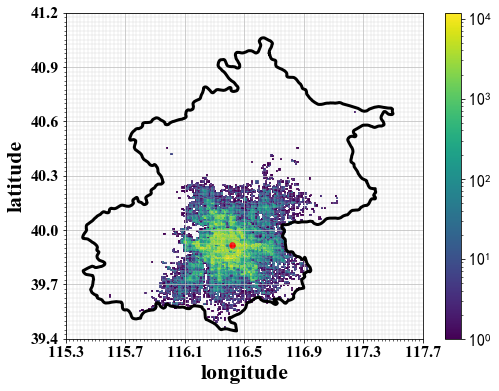

In [6]:
fig= plt.figure(figsize=(8,6))      #起始经纬度
ax = fig.add_subplot(1,1,1) 
 
fig.set_facecolor('white')
plt.plot(bj_x,bj_y,color="black",linewidth="3")
#ax.scatter(sx,sy,marker="s",s=1)
plt.hist2d(sx,sy, bins=180, norm=LogNorm())
cb=plt.colorbar()
cb.ax.tick_params(labelsize=16)
#ax.scatter(ex,ey,marker="s",s=1)
#ax.scatter(ex,ey,alpha=1,label="无往返区域",color="yellow",marker="s",s=1)
#ax.scatter(sx1,sy1,alpha=0.1,label="往返区域",color="green",marker="s",s=1)
#ax.scatter(ex1,ey1,alpha=0.1,label="往返区域",color="green",marker="s",s=1)
#plt.legend(loc="best")
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))#设置x主坐标间隔 1       
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.025))#设置x从坐标间隔 0.1    经度相差1度  距离随纬度变化
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))#设置y主坐标间隔 1
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.025))#设置y从坐标间隔 0.1    纬度相差1度是111公里
ax.grid(which='major', axis='x', linewidth=0.75, linestyle='-', color='0.75')#由每个x主坐标出发对x主坐标画垂直于x轴的线段
ax.grid(which='minor', axis='x', linewidth=0.25, linestyle='-', color='0.75')#由每个x主坐标出发对x主坐标画垂直于x轴的线段
ax.grid(which='major', axis='y', linewidth=0.75, linestyle='-', color='0.75')
ax.grid(which='minor', axis='y', linewidth=0.25, linestyle='-', color='0.75')
#plt.title("All starting points",fontsize=18)    #所有出发点
ax.set_xlabel("longitude",fontdict={'size'   : 22,"family":"Times New Roman"})#经度
ax.set_ylabel("latitude",fontdict={ 'size'   : 22,"family":"Times New Roman"})#纬度
ax.scatter(cx,cy,color="red",s=30)
my_x_ticks = np.arange(115.3, 117.7, 0.4)
plt.xticks(my_x_ticks)
my_y_ticks = np.arange(39.4, 41.2, 0.3)
plt.yticks(my_y_ticks)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman')

plt.tick_params(labelsize=16)
#ax.set_xlim(115.3,117.6)
#ax.set_ylim(39.4,41.2)
plt.savefig('起始点空间分布.pdf')


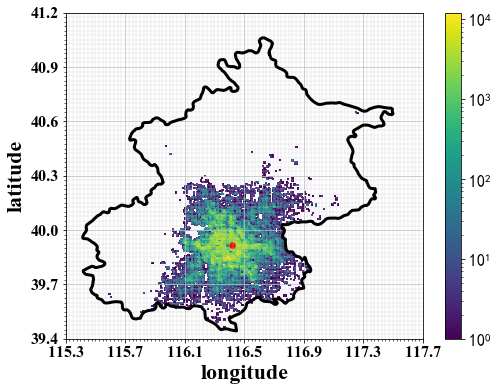

In [7]:
fig= plt.figure(figsize=(8,6))        #终点经纬度
ax = fig.add_subplot(1,1,1) 
 
fig.set_facecolor('white')
plt.plot(bj_x,bj_y,color="black",linewidth="3")
#ax.scatter(sx,sy,marker="s",s=1)
plt.hist2d(ex,ey, bins=180, norm=LogNorm())
cb=plt.colorbar()
cb.ax.tick_params(labelsize=16)
#ax.scatter(ex,ey,marker="s",s=1)
#ax.scatter(ex,ey,alpha=1,label="无往返区域",color="yellow",marker="s",s=1)
#ax.scatter(sx1,sy1,alpha=0.1,label="往返区域",color="green",marker="s",s=1)
#ax.scatter(ex1,ey1,alpha=0.1,label="往返区域",color="green",marker="s",s=1)
#plt.legend(loc="best")
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))#设置x主坐标间隔 1       
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.025))#设置x从坐标间隔 0.1    经度相差1度  距离随纬度变化
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))#设置y主坐标间隔 1
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.025))#设置y从坐标间隔 0.1    纬度相差1度是111公里
ax.grid(which='major', axis='x', linewidth=0.75, linestyle='-', color='0.75')#由每个x主坐标出发对x主坐标画垂直于x轴的线段
ax.grid(which='minor', axis='x', linewidth=0.25, linestyle='-', color='0.75')#由每个x主坐标出发对x主坐标画垂直于x轴的线段
ax.grid(which='major', axis='y', linewidth=0.75, linestyle='-', color='0.75')
ax.grid(which='minor', axis='y', linewidth=0.25, linestyle='-', color='0.75')
#plt.title("All starting points",fontsize=18)    #所有出发点
ax.set_xlabel("longitude",fontdict={'size'   : 22,"family":"Times New Roman"})#经度
ax.set_ylabel("latitude",fontdict={ 'size'   : 22,"family":"Times New Roman"})#纬度
ax.scatter(cx,cy,color="red",s=30)
my_x_ticks = np.arange(115.3, 117.7, 0.4)
plt.xticks(my_x_ticks)
my_y_ticks = np.arange(39.4, 41.2, 0.3)
plt.yticks(my_y_ticks)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman')
plt.tick_params(labelsize=16)
#ax.set_xlim(115.3,117.6)
#ax.set_ylim(39.4,41.2)

plt.savefig('终点空间分布.pdf')